# Joint-ALS soft-constrained PCA

`factors.soft_constrained_pca` minimises

$$\min_{V,\,F}\;\|X - F V^T\|_F^2 \;+\; \sum_j \lambda_j \|v_j - v_j^{(0)}\|^2$$

via alternating least squares, fitting all $k$ factors *jointly*
against a prior loading matrix $V_0$. Different from
`sparse_pca_warm`:

* `sparse_pca_warm` does sequential power iteration with
  deflation; loadings are unit-norm and factors are fit one at
  a time.
* `soft_constrained_pca` is the joint matrix-factorisation
  version; loadings aren't unit-norm and scores absorb the scale.

The Tikhonov penalty drives $V$ toward the prior: $\lambda \to 0$
recovers ordinary PCA (up to rotation), $\lambda \to \infty$
freezes $V$ at $V_0$. `lambda_search` does a chronological
train/val sweep so you can pick the knee by eye.

All analysis is on **daily diffs** of the wide panel.

## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pca import load_long, to_wide, EXPIRY_LABELS, TENOR_LABELS
from factors import soft_constrained_pca, lambda_search

sns.set_theme(style="whitegrid")

rate = to_wide(load_long("../data/mock/rate.pkl")).diff().dropna()
print("rate diff:", rate.shape)

priors_path = Path("../data/priors.pkl")
if not priors_path.exists():
    raise FileNotFoundError(
        f"No prior file at {priors_path.resolve()}. "
        f"Run `streamlit run streamlit_apps/pattern_creator.py` "
        f"and click Save to create one."
    )
saved_priors = pd.read_pickle(priors_path).reindex(
    columns=rate.columns, fill_value=0.0
)
print(f"loaded {len(saved_priors)} priors:", list(saved_priors.index))

def loading_heatmap(ax, w_vec, title, vmax, cbar=False):
    series = pd.Series(w_vec, index=rate.columns)
    grid = series.unstack("tenor").reindex(
        index=[e for e in EXPIRY_LABELS if e in rate.columns.get_level_values("expiry")],
        columns=[t for t in TENOR_LABELS if t in rate.columns.get_level_values("tenor")],
    )
    sns.heatmap(grid, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax, cbar=cbar)
    ax.set_title(title); ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")

rate diff: (499, 204)
loaded 3 priors: ['pattern_1', 'diag_band_2', 'diag_band_3']


## 1. Smoke tests

Two corner cases the spec calls out:

* **`lam = 0, init = "pca"`** should match the top-$k$ PCA
  subspace exactly.
* **`lam = 1e8`** should freeze $V$ at $V_0$.

In [2]:
from sklearn.preprocessing import StandardScaler

k = len(saved_priors)

# (a) lam = 0, init = 'pca' should match the top-k PCA subspace.
fit0 = soft_constrained_pca(rate, saved_priors, lam=0.0, init="pca",
                            max_iter=300, tol=1e-9)
V0_fit = fit0["V"].values.T                       # (N, k)
Xs = StandardScaler().fit_transform(rate.values)
_, _, Vt = np.linalg.svd(Xs, full_matrices=False)
V_pca = Vt[:k].T
Q1, _ = np.linalg.qr(V0_fit)
Q2, _ = np.linalg.qr(V_pca)
cosines = np.linalg.svd(Q1.T @ Q2, compute_uv=False)
print(f"lam=0, init='pca'  | principal-angle cosines = {cosines.round(4)}")
print(f"                    min cosine = {cosines.min():.6f}  "
      f"(1.0 means subspace matches PCA exactly)")

# (b) lam = 1e8 should freeze V at V0.
fit_inf = soft_constrained_pca(rate, saved_priors, lam=1e8, init="prior",
                               max_iter=200, tol=1e-12)
V_inf = fit_inf["V"].values.T
V0_arr = saved_priors.values.T
print(f"\nlam=1e8            | ||V - V0||_F = "
      f"{np.linalg.norm(V_inf - V0_arr):.2e}  (≈ 0 means frozen)")

lam=0, init='pca'  | principal-angle cosines = [1. 1. 1.]
                    min cosine = 1.000000  (1.0 means subspace matches PCA exactly)

lam=1e8            | ||V - V0||_F = 1.33e-06  (≈ 0 means frozen)


## 2. Fit on saved priors — diagnostics

Pick a moderate `lam` (around `2.0`) and inspect per-factor
deviation, prior similarity, and score variance. Side-by-side
heatmaps show the fitted loadings drift toward market structure
while remaining recognisable as the prior.

per-factor diagnostics (lam=2.0):
    pattern  ||v - v0||  cos(v, v0)  score_var
  pattern_1      5.5229      0.4497     1.0060
diag_band_2      6.0099      0.7712     0.3678
diag_band_3      5.8071      0.5355     0.7298

total reconstruction_error = 95079.89
total loading_deviation   = 100.34
objective_history: 96732.39 → 95280.59 (200 iters)


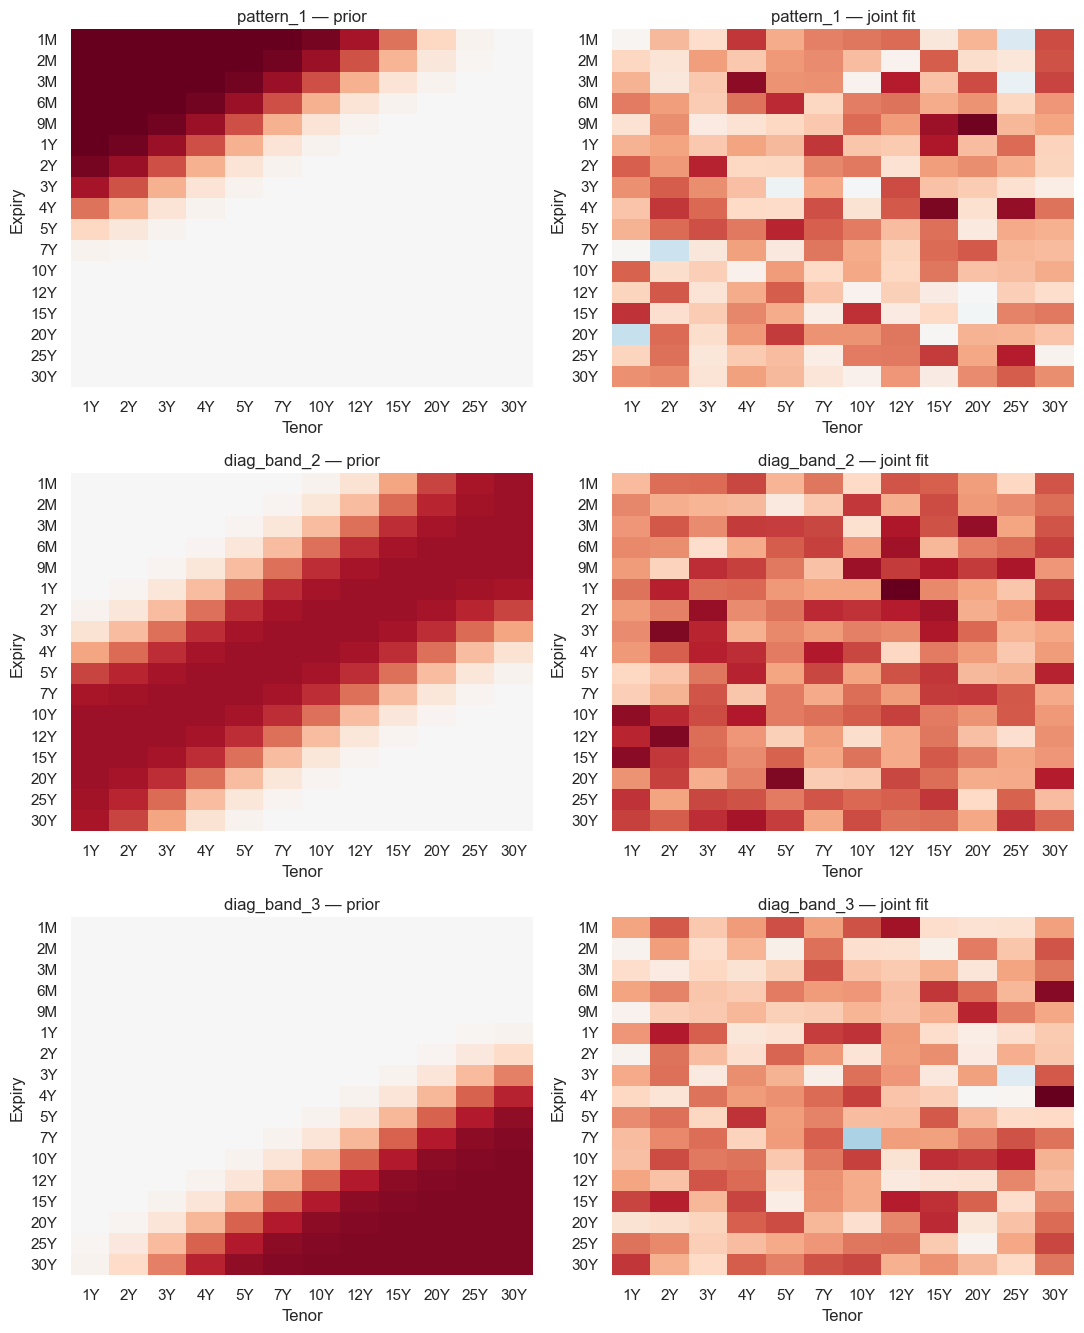

In [3]:
fit = soft_constrained_pca(rate, saved_priors, lam=2.0, init="prior",
                           max_iter=200, tol=1e-7)

rows = []
for name in saved_priors.index:
    v = fit["V"].loc[name].values
    v0 = saved_priors.loc[name].values
    v0n = v0 / (np.linalg.norm(v0) or 1.0)
    vn  = v  / (np.linalg.norm(v)  or 1.0)
    rows.append({
        "pattern":         name,
        "||v - v0||":      float(np.linalg.norm(v - v0)),
        "cos(v, v0)":      float(vn @ v0n),
        "score_var":       float(fit["F"][name].var()),
    })
print("per-factor diagnostics (lam=2.0):")
print(pd.DataFrame(rows).round(4).to_string(index=False))
print(f"\ntotal reconstruction_error = {fit['reconstruction_error']:.2f}")
print(f"total loading_deviation   = {fit['loading_deviation']:.2f}")
print(f"objective_history: {fit['objective_history'][0]:.2f} → "
      f"{fit['objective_history'][-1]:.2f} "
      f"({len(fit['objective_history'])} iters)")

# Side-by-side prior vs fitted loadings (unit-normed for visual fairness).
n_p = len(saved_priors)
fig, axes = plt.subplots(n_p, 2, figsize=(11, 4.5 * n_p), squeeze=False)
for j, name in enumerate(saved_priors.index):
    v = fit["V"].loc[name].values
    v0 = saved_priors.loc[name].values
    v_n  = v  / (np.linalg.norm(v)  or 1.0)
    v0_n = v0 / (np.linalg.norm(v0) or 1.0)
    vmax = max(float(np.abs(v_n).max()), float(np.abs(v0_n).max()), 1e-9)
    loading_heatmap(axes[j, 0], v0_n, f"{name} — prior",     vmax)
    loading_heatmap(axes[j, 1], v_n,  f"{name} — joint fit", vmax)
plt.tight_layout(); plt.show()

## 3. λ sweep — Pareto frontier

Chronological train/val split, fit at each λ on train, evaluate
out-of-sample reconstruction on val. Read it as: lower-right is
"stay close to prior", upper-left is "fit train hard". Pick a
knee point by eye — the helper does not auto-select.

 lambda  val_reconstruction_error  loading_deviation
    0.0                  19813.60             309.96
    0.1                  19812.84             145.31
    0.5                  19810.56             110.36
    1.0                  19808.22             104.93
    2.0                  19804.18             101.62
    5.0                  19794.43              97.68
   10.0                  19782.42              91.29
   50.0                  19765.99               3.80
  100.0                  19768.33               1.05
 1000.0                  19772.87               0.01


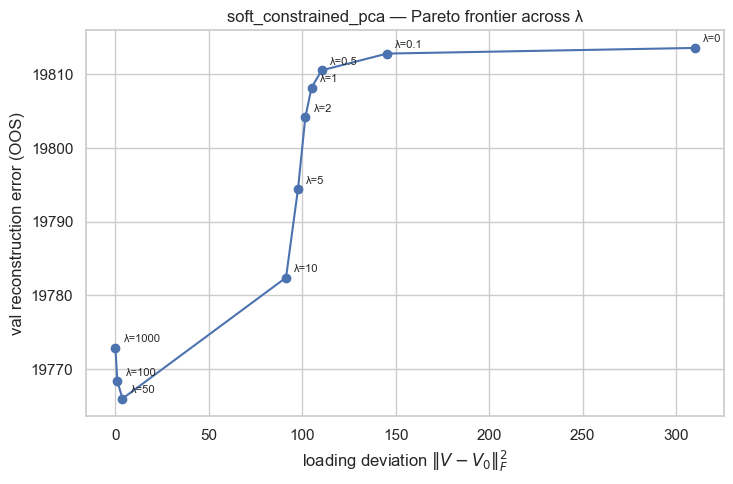

In [4]:
sweep = lambda_search(
    rate, saved_priors,
    lambda_grid=[0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0, 1000.0],
    val_frac=0.2,
)
print(sweep.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(sweep["loading_deviation"], sweep["val_reconstruction_error"],
        marker="o")
for _, r in sweep.iterrows():
    ax.annotate(f"λ={r['lambda']:g}",
                (r["loading_deviation"], r["val_reconstruction_error"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel(r"loading deviation $\|V - V_0\|_F^2$")
ax.set_ylabel("val reconstruction error (OOS)")
ax.set_title("soft_constrained_pca — Pareto frontier across λ")
plt.tight_layout(); plt.show()

## Notes

* `lam` (here) and `anchor` (in `sparse_pca_warm`) play similar
  roles but aren't directly comparable — `lam` is the raw
  Tikhonov weight in the ALS objective, `anchor` is N-scaled to
  a unit knob.
* Same priors work for both algorithms; the difference is
  structural (joint ALS vs deflated power iteration) and shows
  up most clearly when the priors are correlated or when you
  want a clean k-factor subspace.
* See `notebooks/sparse_pca.ipynb` for the `sparse_pca_warm`
  workflow on the same priors.